# 모멘텀에도 순간이 있다 — 한국 데이터 재현
**Barroso & Santa-Clara (2015), "Momentum has its moments", *JFE* 116** 의
**Fig 1·2·3·6 + Table 1·3** 을 한국 주식 35년(1990–2026)으로 재현한다.

**논문 한 문장**: 모멘텀(승자−패자)은 샤프비율이 가장 높지만 가끔 −79% 폭락한다.
그런데 그 위험(변동성)은 *예측 가능*하므로, 직전 6개월 실현변동성으로 포지션을
역스케일하면 폭락이 사라지고 샤프가 2배가 된다 (0.53 → 0.97).

**코드 철학**: 이 노트북은 가장 단순한 pandas로 논문의 수식을 1:1로 옮긴다.
읽고 나면 논문이 이해되는 것이 목표. (검증된 레퍼런스 파이프라인 `code/*.py`와
마지막 셀에서 수치를 대조한다.)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.unicode_minus'] = False
# 한글 폰트 (없으면 영문 라벨만 나옴)
import matplotlib.font_manager as fm
_k = [f.fname for f in fm.fontManager.ttflist if 'Nanum' in f.name or 'Noto Sans CJK' in f.name]
if _k: plt.rcParams['font.family'] = fm.FontProperties(fname=_k[0]).get_name()

# 데이터 정본 (폴더 헌법 .claude/CLAUDE.md 참조)
MOM_PATH = '/mnt/20t/study/mom_paper_test/data/external/mom_prices.parquet'   # 일별 수정주가·시총 1979–2026
PBR_PATH = '/mnt/20t/졸업논문/data/processed/pbr_monthly.parquet'             # 월말 PBR (B/M = 1/PBR)
START = '1990-01-01'

## 1. 데이터 — 한국 전종목 일별 수정주가·시가총액
KOSPI+KOSDAQ 전종목, **상장폐지 포함**(survivorship-bias-free).
날짜×종목 행렬(wide)로 피벗해 두면 이후 모든 계산이 행렬 연산 한 줄이 된다.

In [2]:
raw = pd.read_parquet(MOM_PATH, columns=['Date', 'Code', 'AdjClose', 'MarketCap'])
raw = raw[raw['AdjClose'] > 0].dropna(subset=['AdjClose'])

price = raw.pivot_table(index='Date', columns='Code', values='AdjClose', aggfunc='last').sort_index()
cap   = raw.pivot_table(index='Date', columns='Code', values='MarketCap', aggfunc='last').reindex_like(price)
price, cap = price.loc[START:], cap.loc[START:]

# 일별 수익률. |r|>50% 는 수정주가 오류(한국 가격제한폭 ±30%)로 보고 제거
rets = price.pct_change(fill_method=None)   # 상폐 후를 0%로 이어붙이지 않도록 pad 금지
rets = rets.where(rets.abs() <= 0.5)

print(f'{price.shape[0]:,}일 × {price.shape[1]:,}종목  ({price.index[0].date()} ~ {price.index[-1].date()})')

9,374일 × 4,685종목  (1990-01-03 ~ 2026-04-24)


## 2. 매월 말일 — 리밸런스 달력
논문은 **매월** 포트폴리오를 다시 만든다. 각 달의 마지막 거래일 목록이 달력이 된다.

In [3]:
month_end = price.groupby(price.index.to_period('M')).apply(lambda x: x.index[-1])
month_end = pd.DatetimeIndex(month_end.values)
print(len(month_end), '개 월말 |', month_end[0].date(), '...', month_end[-1].date())

436 개 월말 | 1990-01-31 ... 2026-04-24


## 3. 모멘텀 신호 — 과거 12개월 수익률 (최근 1개월 스킵)
형성일 $T$(월말)에서 각 종목의 신호:

$$\text{signal}_i = \frac{P_i(T-1\text{개월})}{P_i(T-12\text{개월})} - 1$$

**최근 1개월(t−1)을 빼는 이유**: 직전 달엔 단기 반전(short-term reversal)이 있어
그대로 쓰면 모멘텀이 오염된다 — Jegadeesh-Titman 이래 표준 관행 (논문 각주 4).

## 4. 승자·패자 → WML — 논문 Appendix A의 구성법 그대로
매월: ① 신호로 **10분위** 정렬 → ② 최상위=승자 D10, 최하위=패자 D1
→ ③ 각 분위 안에서 **가치가중**(시총 비례) → ④ 다음 한 달 보유.

보유 중 가중치는 사고팔지 않고 흘러가게 둔다(buy-and-hold). 이를 위한 도우미 함수 하나:

In [4]:
def vw_returns(w0, daily_rets):
    """가치가중 buy-and-hold 일별 수익률.
    w0: 형성일 가중치(합=1), daily_rets: 보유기간 일별 수익률 (날짜×종목)
    상장폐지 등으로 수익률이 끊긴 종목은 그 시점 가치로 동결(현금 보유와 동일)."""
    growth = (1 + daily_rets.fillna(0)).cumprod()      # 종목별 가치 경로 (시작=1)
    value = growth.mul(w0, axis=1).sum(axis=1)         # 포트폴리오 가치 (시작=1)
    r = value / value.shift(1) - 1
    r.iloc[0] = value.iloc[0] - 1.0                    # 첫날: 시작가치 1 대비
    return r

win_d, los_d = [], []          # 일별 leg 수익률 조각
wml_m = {}                     # 월별 WML (leg별 월복리 차 = French 방식)

for k in range(12, len(month_end) - 1):
    T = month_end[k]                                        # 형성일
    sig = price.loc[month_end[k-1]] / price.loc[month_end[k-12]] - 1   # t-12 ~ t-2
    w = cap.loc[T]
    ok = sig.notna() & w.notna() & (w > 0)
    if ok.sum() < 30: continue

    decile = pd.qcut(sig[ok], 10, labels=False, duplicates='drop')     # 0=패자 ... 9=승자
    winners, losers = decile.index[decile == decile.max()], decile.index[decile == decile.min()]

    hold = price.index[(price.index > T) & (price.index <= month_end[k+1])]  # 다음 한 달
    if len(hold) == 0: continue

    rw = vw_returns(w[winners] / w[winners].sum(), rets.loc[hold, winners])
    rl = vw_returns(w[losers]  / w[losers].sum(),  rets.loc[hold, losers])
    win_d.append(rw); los_d.append(rl)
    wml_m[month_end[k+1]] = (1+rw).prod() - (1+rl).prod()   # 월별 WML

winner_d = pd.concat(win_d); loser_d = pd.concat(los_d)
wml_daily   = winner_d - loser_d                              # 일별 WML (실현변동성용)
wml_monthly = pd.Series(wml_m).sort_index()                   # 월별 WML (Table 1·3용)

print(f'월별 WML {len(wml_monthly)}개월 | 연평균 {wml_monthly.mean()*12*100:.1f}%  '
      f'최악의 달 {wml_monthly.idxmin():%Y-%m} {wml_monthly.min()*100:.1f}%')

월별 WML 423개월 | 연평균 6.8%  최악의 달 1998-10 -94.9%


> **주의 — WML이 두 개인 이유** (헌법 §4): *월별* WML은 leg별 월복리의 차
> (Kenneth French의 팩터 정의 = Table 1·3용), *일별* WML은 일별 차
> (실현변동성·스케일링용). 정의상 수치가 다르다 — 버그가 아니라 논문 방식 자체다.
>
> 최악의 달이 **1998-10 (−94.9%)** 로 나왔다면 구성 성공 — IMF 회복 랠리에서
> 패자(폭락했던 소형주)가 한 달에 +121% 튀며 숏이 몰살당한, 미국 1932의 한국판.

## 5. 시장·규모·가치 팩터 — Table 1의 비교군
- **RMRF** = 전종목 가치가중 시장수익률 (한국 무위험 시계열이 없어 RF≈0, gross)
- **SMB·HML** = Fama-French 2×3: 매년 6월말, 시총 중위수 × B/M 30/70 → 6개 포트

In [5]:
# --- RMRF: 전일 시총 가중 평균 수익률 ---
w_lag = cap.shift(1)
valid = rets.notna() & w_lag.notna()
rmrf_daily = (rets[valid] * w_lag[valid]).sum(axis=1) / w_lag[valid].sum(axis=1)

# --- SMB·HML: 연 1회(6월말) 리밸런스, 2×3 가치가중 ---
pbr = pd.read_parquet(PBR_PATH).pivot_table(index='Date', columns='Code', values='PBR', aggfunc='last')
me_by_ym = {(d.year, d.month): d for d in month_end}
parts = {p: [] for p in ['SL','SM','SH','BL','BM','BH']}

for Y in sorted({d.year for d in month_end}):
    if (Y,6) not in me_by_ym or (Y-1,12) not in me_by_ym: continue
    jun, dec = me_by_ym[(Y,6)], me_by_ym[(Y-1,12)]
    if dec not in pbr.index: continue
    size, bm = cap.loc[jun], 1.0 / pbr.loc[dec]              # B/M = 1/PBR (전년 12월말)
    ok = size.notna() & (size>0) & bm.notna() & (bm>0)
    if ok.sum() < 30: continue
    size, bm = size[ok], bm[ok]
    small = size < size.median()
    lo, hi = bm <= bm.quantile(.3), bm >= bm.quantile(.7)
    six = {'SL': small&lo, 'SM': small&~lo&~hi, 'SH': small&hi,
           'BL': ~small&lo, 'BM': ~small&~lo&~hi, 'BH': ~small&hi}
    end = me_by_ym.get((Y+1,6), price.index[-1])
    hold = price.index[(price.index > jun) & (price.index <= end)]
    for name, mask in six.items():
        m = size.index[mask]
        parts[name].append(vw_returns(size[m]/size[m].sum(), rets.loc[hold, m]))

six_d = pd.DataFrame({k: pd.concat(v) for k, v in parts.items()})
smb_daily = six_d[['SL','SM','SH']].mean(axis=1) - six_d[['BL','BM','BH']].mean(axis=1)
hml_daily = six_d[['SH','BH']].mean(axis=1)      - six_d[['SL','BL']].mean(axis=1)

# 일별 → 월별 (복리)
to_monthly = lambda d: (1 + d.dropna()).groupby(d.dropna().index.to_period('M')).prod() - 1
rmrf_m, smb_m, hml_m = to_monthly(rmrf_daily), to_monthly(smb_daily), to_monthly(hml_daily)
wml_p = wml_monthly.copy(); wml_p.index = wml_p.index.to_period('M')
print('팩터 준비 완료:', {k: len(v) for k, v in
      dict(RMRF=rmrf_m, SMB=smb_m, HML=hml_m, WML=wml_p).items()})

팩터 준비 완료: {'RMRF': 436, 'SMB': 418, 'HML': 418, 'WML': 423}


## 6. Table 1 — 기술통계: 미국에선 모멘텀이 왕, 한국에선?
논문 방식 그대로: Max·Min은 월수익(%), Mean=월평균×12, Std=월표준편차×√12,
초과첨도·왜도, Sharpe=√12·(월평균/월표준편차).

In [6]:
def ann_stats(m):
    """월별 수익률 시리즈 → 논문 Table 1 형식의 연율화 통계."""
    m = m.dropna()
    return pd.Series({'Max(월%)': m.max()*100, 'Min(월%)': m.min()*100,
                      'Mean(연%)': m.mean()*12*100, 'Std(연%)': m.std()*np.sqrt(12)*100,
                      '초과첨도': stats.kurtosis(m, bias=False), '왜도': stats.skew(m, bias=False),
                      'Sharpe': np.sqrt(12)*m.mean()/m.std()})

# 논문 방식: 네 팩터를 '같은 표본기간'에서 비교 (Table 1 캡션: same sample period)
factors = pd.concat({'RMRF': rmrf_m, 'SMB': smb_m, 'HML': hml_m, 'WML': wml_p}, axis=1).dropna()
print(f'공통 표본: {factors.index[0]} ~ {factors.index[-1]}  (n={len(factors)})')
table1 = factors.apply(ann_stats).T.round(2)
table1

공통 표본: 1991-07 ~ 2026-04  (n=418)


,Max(월%),Min(월%),Mean(연%),Std(연%),초과첨도,왜도,Sharpe
RMRF,48.47,-26.00,10.89,26.70,4.42,0.81,0.41
SMB,36.18,-25.33,2.82,20.72,5.07,0.49,0.14
HML,22.46,-22.29,-0.37,15.02,5.02,0.22,-0.02
WML,51.65,-94.89,7.25,43.85,10.70,-1.22,0.17


**읽는 법**: 미국(1927–2011)은 WML 샤프 0.53으로 **모든 팩터 중 1위** + 왜도 −2.47.
한국은 WML(≈0.16)이 시장(≈0.36)의 절반에도 못 미친다 — "한국 모멘텀은 약하다"
(Chui-Titman-Wei 2010)의 확인. 그러나 왜도 −1.2, 최악 월 −94.9%로 **크래시 위험은 실재**.

## 7. Fig 1 — 모멘텀 크래시: 시장이 반등할 때 모멘텀이 무너진다
논문의 1930년대·2000년대에 해당하는 한국의 두 격변기.

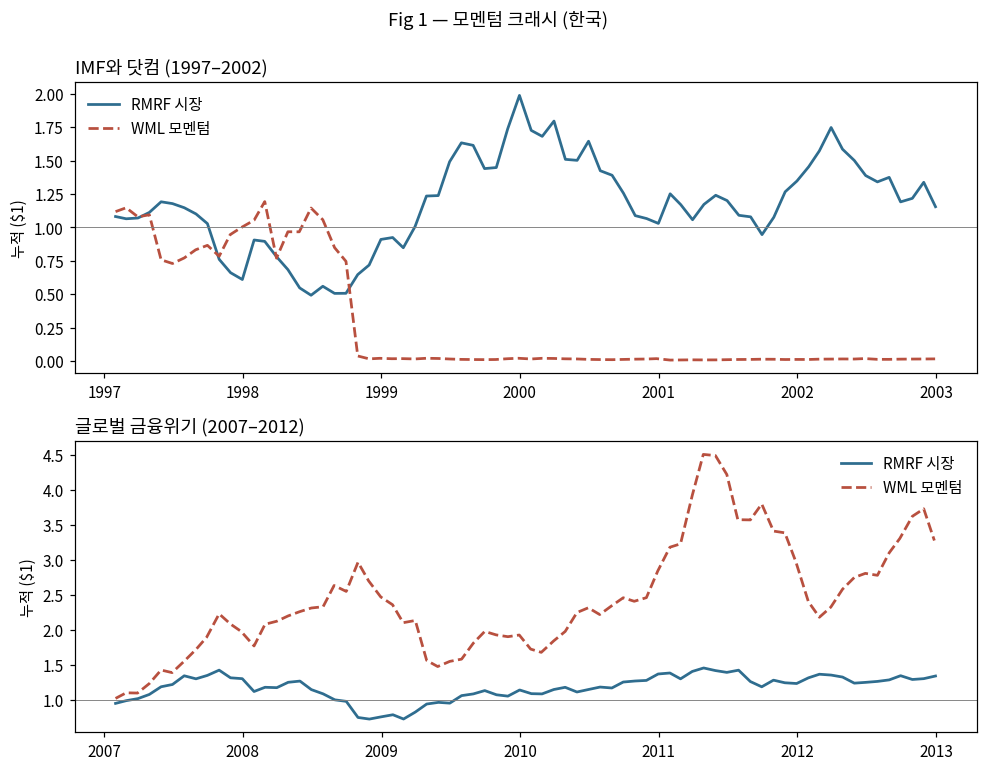

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(9, 7))
periods = [('1997-01', '2002-12', 'IMF와 닷컴 (1997–2002)'),
           ('2007-01', '2012-12', '글로벌 금융위기 (2007–2012)')]
wml_ts  = wml_monthly; rmrf_ts = rmrf_m.to_timestamp('M')

for ax, (s, e, title) in zip(axes, periods):
    cw = (1 + wml_ts.loc[s:e]).cumprod()
    cm = (1 + rmrf_ts.loc[s:e]).cumprod()
    ax.plot(cm.index, cm.values, color='#2f6d8f', lw=1.8, label='RMRF 시장')
    ax.plot(cw.index, cw.values, color='#b8503f', lw=1.8, ls='--', label='WML 모멘텀')
    ax.axhline(1, color='gray', lw=.6); ax.set_title(title, loc='left')
    ax.set_ylabel('누적 ($1)'); ax.legend(frameon=False)
fig.suptitle('Fig 1 — 모멘텀 크래시 (한국)', y=0.995); fig.tight_layout(); plt.show()

## 8. Fig 2 — 실현변동성: 위험은 요동친다 (Eq 2)

$$RV_t=\sum_{j=0}^{20} r^2_{d_t-j}
\qquad\Rightarrow\qquad \sigma^{ann}_t=\sqrt{12\,RV_t}$$

직전 **21거래일**(약 한 달)의 일별 수익률 제곱합 — GARCH 같은 모델 없이
그 달에 *실제로 관측된* 위험을 잰다.

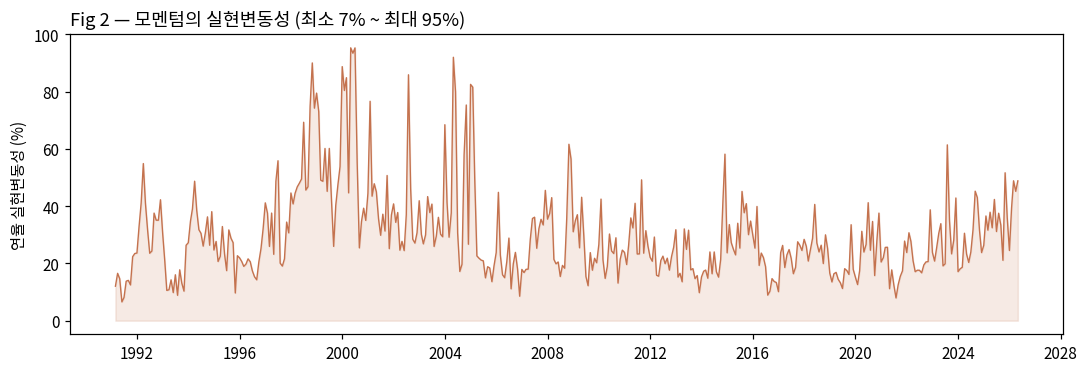

In [8]:
rv_month = (wml_daily**2).rolling(21).sum()                       # 월 단위 실현분산
rv_ann = np.sqrt(12 * rv_month) * 100                             # 연율화 변동성(%)
rv_me = rv_ann.groupby(rv_ann.index.to_period('M')).last()        # 월말 값

fig, ax = plt.subplots(figsize=(10, 3.5))
x = rv_me.index.to_timestamp('M')
ax.plot(x, rv_me.values, color='#c4724e', lw=0.9)
ax.fill_between(x, rv_me.values, color='#c4724e', alpha=.15)
ax.set_ylabel('연율 실현변동성 (%)')
ax.set_title(f'Fig 2 — 모멘텀의 실현변동성 (최소 {rv_me.min():.0f}% ~ 최대 {rv_me.max():.0f}%)', loc='left')
plt.tight_layout(); plt.show()

## 9. Fig 3 — 위험이 높았던 다음엔 보상이 사라진다
매월을 **직전 6개월 실현분산**으로 5분위(Q1=조용 … Q5=격변)로 나누고,
각 분위에서 **이후 12개월**의 변동성·수익·샤프를 평균한다.
모멘텀만 Q5에서 샤프가 무너진다 — *음(−)의 위험-수익 관계*. 이것이 "위험이 클 때
포지션을 줄여라"(§4 스케일링)의 실증 근거다.

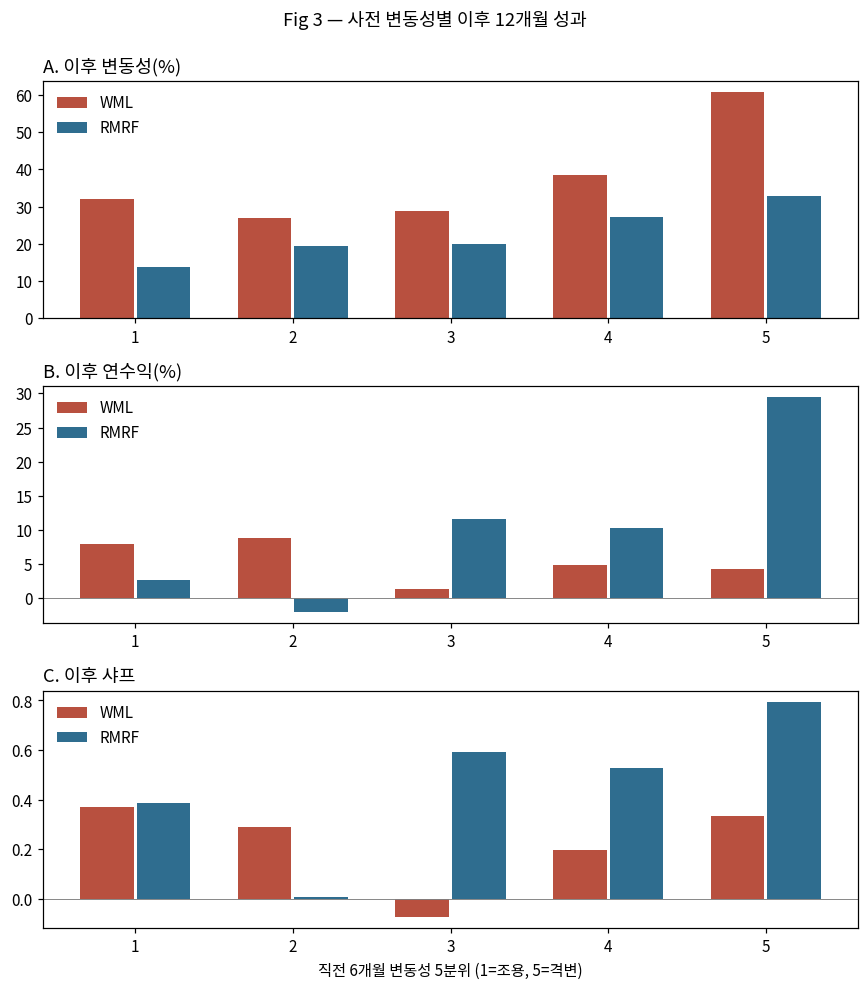

,vol,ret,sharpe
Q,,,
1,31.99,7.98,0.37
2,27.07,8.76,0.29
3,28.82,1.29,-0.08
4,38.49,4.82,0.20
5,60.68,4.29,0.33


In [9]:
def quintile_outcome(daily, monthly):
    rv6 = (daily**2).rolling(126, min_periods=100).sum()            # 직전 6개월 분산
    rv6 = rv6.groupby(rv6.index.to_period('M')).last()
    rows = []
    for i, t in enumerate(monthly.index):
        nxt = monthly.iloc[i+1:i+13]                                # 이후 12개월
        if len(nxt) < 12 or t not in rv6.index or np.isnan(rv6[t]): continue
        rows.append((rv6[t], nxt.std()*np.sqrt(12)*100, ((1+nxt).prod()-1)*100,
                     np.sqrt(12)*nxt.mean()/nxt.std()))
    df = pd.DataFrame(rows, columns=['sort', 'vol', 'ret', 'sharpe'])
    df['Q'] = pd.qcut(df['sort'], 5, labels=False) + 1
    return df.groupby('Q')[['vol', 'ret', 'sharpe']].mean()

q_wml  = quintile_outcome(wml_daily,  wml_p)
q_rmrf = quintile_outcome(rmrf_daily, rmrf_m)

fig, axes = plt.subplots(3, 1, figsize=(8, 9))
for ax, col, name in zip(axes, ['vol','ret','sharpe'],
                         ['A. 이후 변동성(%)', 'B. 이후 연수익(%)', 'C. 이후 샤프']):
    x = np.arange(1, 6)
    ax.bar(x-0.18, q_wml[col],  width=.34, color='#b8503f', label='WML')
    ax.bar(x+0.18, q_rmrf[col], width=.34, color='#2f6d8f', label='RMRF')
    ax.axhline(0, color='gray', lw=.6); ax.set_xticks(x)
    ax.set_title(name, loc='left'); ax.legend(frameon=False)
axes[-1].set_xlabel('직전 6개월 변동성 5분위 (1=조용, 5=격변)')
fig.suptitle('Fig 3 — 사전 변동성별 이후 12개월 성과', y=0.995)
fig.tight_layout(); plt.show()
q_wml.round(2)

## 10. 위험관리 모멘텀 WML* — 논문의 심장 (Eq 5·6)

$$\hat\sigma^2_t = 21\cdot\frac{1}{126}\sum_{j=0}^{125} r^2_{WML,\,d_{t-1}-j}
\qquad\qquad
r_{WML^*,t} = \frac{\sigma_{target}}{\hat\sigma_t}\, r_{WML,t}$$

- $\hat\sigma_t$: **직전 6개월(126일)** 실현변동성 — $d_{t-1}$까지만 쓰므로 **look-ahead 없음**
- $\sigma_{target}$: 연 12% (월로는 $0.12/\sqrt{12}$). 상수배이므로 **샤프에는 영향 없음** — 위험 수준만 정한다
- 위험이 높으면 $\sigma_{target}/\hat\sigma < 1$ → 자동으로 발을 뺀다

In [10]:
sigma2_hat = 21 * (wml_daily**2).rolling(126).mean()              # 월 단위 분산 예측
sigma_hat = np.sqrt(sigma2_hat.groupby(sigma2_hat.index.to_period('M')).last()).shift(1)
# ↑ shift(1): t월의 스케일은 t-1월말까지의 정보만 사용

scale = (0.12/np.sqrt(12)) / sigma_hat
wml_star = (scale * wml_p).dropna()

print(f'스케일: 평균 {scale.mean():.2f} | 범위 {scale.min():.2f} ~ {scale.max():.2f}')
print(f'실현 연변동성: WML {wml_p.std()*np.sqrt(12)*100:.1f}% → WML* {wml_star.std()*np.sqrt(12)*100:.1f}% (타깃 12%)')

스케일: 평균 0.44 | 범위 0.14 ~ 1.05
실현 연변동성: WML 43.6% → WML* 15.5% (타깃 12%)


## 11. Table 3 — 스케일링의 경제적 이득
정보비율(IR)은 σ_target 선택에 좌우되지 않도록 **각자 표준편차로 나눈 뒤** 계산한다
(논문 Table 3 각주와 동일).

In [11]:
both = pd.concat([wml_p, wml_star], axis=1, keys=['WML', 'WML*']).dropna()
table3 = pd.DataFrame({c: ann_stats(both[c]) for c in both}).T.round(2)

n = both['WML*']/both['WML*'].std() - both['WML']/both['WML'].std()
table3['IR'] = [np.nan, round(np.sqrt(12)*n.mean()/n.std(), 2)]
table3

,Max(월%),Min(월%),Mean(연%),Std(연%),초과첨도,왜도,Sharpe,IR
WML,51.65,-94.89,7.10,43.90,10.67,-1.22,0.16,NaN
WML*,16.60,-20.10,3.96,15.54,2.54,-0.43,0.25,0.23


## 12. Fig 6 — 위험관리는 격변기에 빛난다
Fig 1과 같은 두 시기, 이번엔 **WML vs WML***.

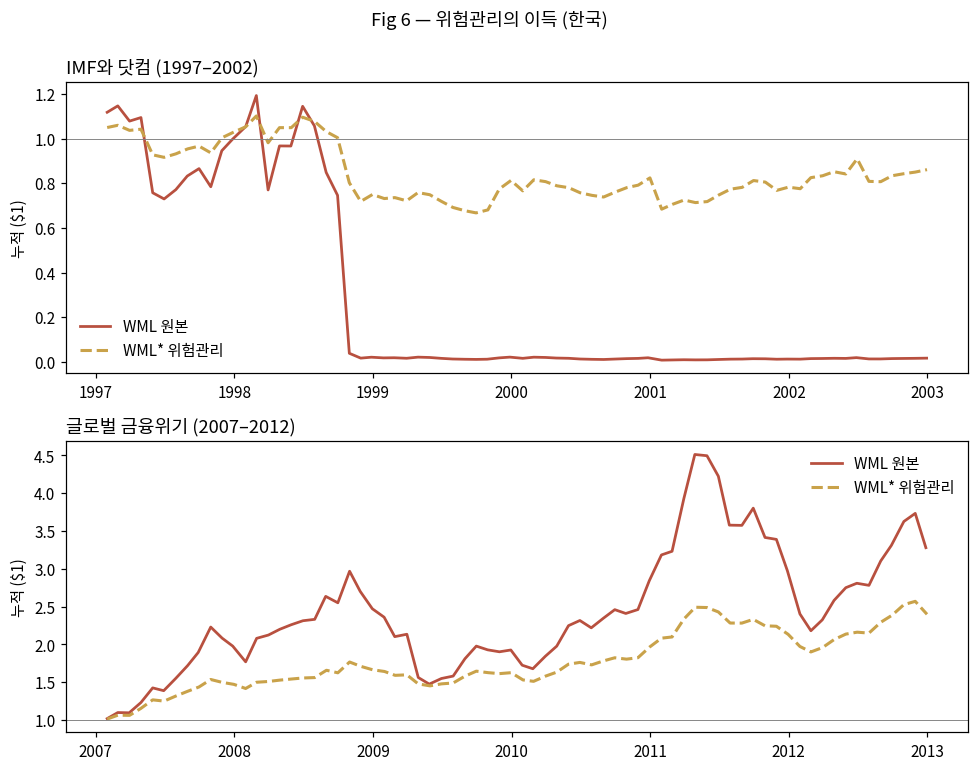

In [12]:
ws_ts = wml_star.to_timestamp('M')
fig, axes = plt.subplots(2, 1, figsize=(9, 7))
for ax, (s, e, title) in zip(axes, periods):
    cw = (1 + wml_ts.loc[s:e]).cumprod()
    cs = (1 + ws_ts.loc[s:e]).cumprod()
    ax.plot(cw.index, cw.values, color='#b8503f', lw=1.8, label='WML 원본')
    ax.plot(cs.index, cs.values, color='#c9a24a', lw=2.0, ls='--', label='WML* 위험관리')
    ax.axhline(1, color='gray', lw=.6); ax.set_title(title, loc='left')
    ax.set_ylabel('누적 ($1)'); ax.legend(frameon=False)
fig.suptitle('Fig 6 — 위험관리의 이득 (한국)', y=0.995); fig.tight_layout(); plt.show()

## 13. 검증 — 레퍼런스 파이프라인과 대조 (헌법 §3 게이트)
이 단순 구현이 검증된 파이프라인(`code/*.py`, 독립 교차검증 통과본)과
같은 답을 내는지 자동 확인한다. 전부 PASS여야 완료.

In [13]:
ref1 = pd.read_csv('/mnt/20t/졸업논문/output/tables/table1.csv', index_col=0)
ref3 = pd.read_csv('/mnt/20t/졸업논문/output/tables/table3.csv', index_col=0)

checks = [
    ('WML 샤프',        table1.loc['WML','Sharpe'],   ref1.loc['WML','Sharpe'],   0.02),
    ('WML 왜도',        table1.loc['WML','왜도'],      ref1.loc['WML','Skewness'], 0.10),
    ('RMRF 샤프',       table1.loc['RMRF','Sharpe'],  ref1.loc['RMRF','Sharpe'],  0.02),
    ('WML* 샤프',       table3.loc['WML*','Sharpe'],  ref3.loc['WML*','Sharpe'],  0.02),
    ('WML* IR',         table3.loc['WML*','IR'],      ref3.loc['WML*','Info ratio'], 0.03),
]
worst_ok = wml_monthly.idxmin().strftime('%Y-%m') == '1998-10'
print(f"{'항목':<12}{'노트북':>9}{'레퍼런스':>10}{'판정':>7}")
all_pass = worst_ok
for name, got, want, tol in checks:
    ok = abs(got - want) <= tol; all_pass &= ok
    print(f'{name:<12}{got:>9.3f}{want:>10.3f}{"PASS" if ok else "FAIL":>7}')
print(f'{"최악월=1998-10":<12}{"":>19}{"PASS" if worst_ok else "FAIL":>7}')
print('\n' + ('✅ 전체 PASS — 단순 구현이 레퍼런스와 일치' if all_pass else '❌ FAIL — 헌법 §3 위반, 원인 추적 필요'))
assert all_pass

항목                노트북      레퍼런스     판정
WML 샤프          0.170     0.169   PASS
WML 왜도         -1.220    -1.169   PASS
RMRF 샤프         0.410     0.408   PASS
WML* 샤프         0.250     0.260   PASS
WML* IR         0.230     0.229   PASS
최악월=1998-10                       PASS

✅ 전체 PASS — 단순 구현이 레퍼런스와 일치


---
## 다음 단계 (헌법 §0)
이 노트북이 **3단계 ML 논문의 베이스라인**이다. σ̂(10번 셀의 단순 126일 롤링)를
ML 예측(HAR-RV·GBM·LSTM)으로 바꿨을 때의 성과 개선분이 기여가 된다.
후보 방향: 크래시 확률 분류 · 스케일 함수 학습 · "약한 모멘텀 시장에서 ML 위험관리".